# Expanding Safe Parking for Urban Vehicle Residents Analysis

*UP213 Urban Data Science SQ25*

**Group Members:** Simon Han, Tomohiro Ujikawa

## Objective
Our project aims to address vehicle living in LA by identifying where vehicle residents are clustered and where there could be safe and sanctioned places to park at night, particularly in areas with excess capacity through city parking garages.

## Background
Vehicle residency is rising among working-class individuals and families as housing costs outpace wages in Los Angeles. Safe parking programs offer legal overnight parking for vehicle residents along with access to restrooms and supportive services. However, the transient and discreet nature of many vehicle residents poses operational challenges for these programs. In addition, long waitlists and limited capacity at individual sites often discourage those with urgent needs from enrolling. To address these gaps, it is essential to better align areas of high need with high-capacity parking facilities that can operate with minimal staffing and oversight.

## Key Questions
- Where are the vehicle homeless clusters in Los Angeles?
- Where are parking facilities with high capacity in areas with high need?

## Dataset
- **LAHSA Homeless Count**: vehicle dwelling counts by tract
- **ACS**: poverty, rent burden, vehicle ownership, housing overcrowding, etc.
- **TIGER/Line**: Census tract boundaries for spatial analysis
- **SCAG 2019 Regional Land Use Type**: public parking facilities (LU19 code 1247)
- **Public Facilities Data**: Locations of essential services (hospitals, schools, transportation hubs, and food pantries)

## Methods
- **Spatial Joins** to overlay homelessness data with garage locations
- **Random Forests** to predict vehicle homelessness based on demographic and economic factors
- **Cluster Analysis** to identify different typologies of vehicle homelessness
- **Visualization** of results through various maps and charts

# Data Preparation

Load required libraries and prepare geographic boundaries for analysis.

In [1]:
import contextily as ctx
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import requests
import seaborn as sns
import zipfile
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import PartialDependenceDisplay
from sklearn.model_selection import train_test_split
from sklearn import metrics, preprocessing

In [2]:
# Load Tiger/Line census tract boundaries
drop_geoids = ['06037990100', '06037990200', '06037990300']

for year in range(2019, 2025):
    path = f"Data/tl_shp_library/tl_{year}_06_tract.zip"
    tracts = gpd.read_file(path)
    la_tracts = tracts[(tracts["COUNTYFP"] == "037") & (tracts["STATEFP"] == "06")]
    la_tracts = la_tracts.set_index('GEOID')
    la_tracts = la_tracts.drop(index=drop_geoids, errors='ignore')
    
    var_name = f"tracts{str(year)[-2:]}"
    globals()[var_name] = la_tracts

<div class="alert alert-block alert-info">
<h3>Key Takeaways</h3>
<ul>
<li>Census tract boundaries loaded for 2019-2024</li>
<li>Catalina Island tract GEOIDs removed</li>
</ul>
</div>

# Land Use Analysis

Analyze land use patterns to understand residential concentration and parking availability.

In [3]:
# Load SCAG land use data
with zipfile.ZipFile("Data/landuse.gpkg.zip", 'r') as zip_ref:
    zip_ref.extractall("Data/")
luGdf = gpd.read_file("Data/landuse.gpkg")

# Select relevant columns
selected_cols = ['ACRES', 'GEOID20', 'DEN_AVG', 'ZN19_SCAG', 'LU19', 'geometry']
luGdf = luGdf[selected_cols]

# Create major land use categories
luGdf['LU19'] = pd.to_numeric(luGdf['LU19'], errors='coerce')
lu19_major_categories = {
    1100: "Residential",
    1200: "Commercial and Services",
    1300: "Industrial",
    1400: "Transportation, Communications, and Utilities",
    1500: "Public Facilities",
    1600: "Open Space and Recreation",
    1700: "Vacant",
    1800: "Water",
    1900: "Agriculture",
    8888: "Undevelopable or Protected Land",
    9999: "LandUnknown"
}

luGdf['LU19_major_code'] = (luGdf['LU19'] // 100) * 100
luGdf.loc[luGdf['LU19'] == 8888, 'LU19_major_code'] = 8888
luGdf.loc[luGdf['LU19'] == 9999, 'LU19_major_code'] = 9999
luGdf['LU19_major_label'] = luGdf['LU19_major_code'].map(lu19_major_categories)

/opt/anaconda3/lib/python3.11/site-packages/pyogrio/raw.py:198: RuntimeWarning: Non-conformant content for record 1 in column YEAR_GP, 2015-05-01T00:00:00.0Z, successfully parsed
  return ogr_read(


In [4]:
# Calculate residential land use proportion by tract
luGdf['GEOID'] = luGdf['GEOID20'].str[:11]
luGdf_proj = luGdf.to_crs(epsg=3497)
luGdf_proj['area_m2'] = luGdf_proj.geometry.area

tract_lu = luGdf_proj.groupby(['GEOID', 'LU19_major_label'])['area_m2'].sum().reset_index()
tract_total = tract_lu.groupby('GEOID')['area_m2'].sum().reset_index(name='total_area_m2')
tract_lu = tract_lu.merge(tract_total, on='GEOID')
tract_lu['percent'] = tract_lu['area_m2'] / tract_lu['total_area_m2'] * 100

tract_residential = tract_lu[tract_lu['LU19_major_label'] == 'Residential'][['GEOID', 'percent']]
tract_residential = tract_residential.rename(columns={'percent': 'pct_residential'})

<div class="alert alert-block alert-info">
<h3>Key Takeaways</h3>
<ul>
<li>Land use categorized into 11 major types from SCAG 2019 data</li>
<li>Residential land use proportion calculated for each census tract</li>
</ul>
</div>

# Amenities Analysis

Count public facilities and parking within buffer zones around census tracts.

In [5]:
# Create 2000m buffers around tracts
tracts23_buffer = tracts23.to_crs(epsg=3497)
tracts23_buffer["geometry"] = tracts23_buffer.buffer(2000)

In [6]:
# Load public facilities data
ArtsRecreation = gpd.read_file("data/public_facilities/ArtsRecreation.gpkg").to_crs(epsg=3497)
Education = gpd.read_file("data/public_facilities/Education.gpkg").to_crs(epsg=3497)
Hospitals = gpd.read_file("data/public_facilities/Hospitals.gpkg").to_crs(epsg=3497)
MunicipalServices = gpd.read_file("data/public_facilities/MunicipalServices.gpkg").to_crs(epsg=3497)
PhysicalFeatures = gpd.read_file("data/public_facilities/PhysicalFeatures.gpkg").to_crs(epsg=3497)
PublicSafety = gpd.read_file("data/public_facilities/PublicSafety.gpkg").to_crs(epsg=3497)
Transportation = gpd.read_file("data/public_facilities/Transportation.gpkg").to_crs(epsg=3497)

# Remove jails from public safety facilities
PublicSafety = PublicSafety[~PublicSafety["cat2"].isin([
    "Jails and Prisons",
    "Probation Camps and Juvenile Halls"
])].reset_index(drop=True)

# Load food pantries
pantryDf = pd.read_csv('data/Food_Resources_in_California.csv')
pantryDf = pantryDf[pantryDf.County=='Los Angeles']
Pantry = gpd.GeoDataFrame(
    pantryDf, geometry=gpd.points_from_xy(pantryDf.Longitude, pantryDf.Latitude, 
                                          crs='EPSG:4326'))
Pantry = Pantry.to_crs(epsg=3497)

# Extract parking lots from land use data
Parking = luGdf[luGdf['LU19'] == 1247].to_crs(epsg=3497)
Parking = Parking.set_index('GEOID')
Parking['geometry'] = Parking.centroid

/opt/anaconda3/lib/python3.11/site-packages/pyogrio/raw.py:198: RuntimeWarning: Non-conformant content for record 1 in column last_update, 2025-03-10T00:00:00.0Z, successfully parsed
  return ogr_read(
/opt/anaconda3/lib/python3.11/site-packages/pyogrio/raw.py:198: RuntimeWarning: Non-conformant content for record 177 in column last_update, 2025-04-04T13:03:56.0Z, successfully parsed
  return ogr_read(


In [7]:
# Count facilities within tract buffers
def count_facilities_within_tracts(tracts_gdf, points_gdf, buffer_gdf_name):
    tmp = gpd.sjoin(tracts_gdf, points_gdf, predicate='intersects')
    counts = tmp.groupby('GEOID').size()
    counts.name = f'n_{buffer_gdf_name}'
    tracts_gdf = tracts_gdf.join(counts)
    tracts_gdf.fillna({f'n_{buffer_gdf_name}': 0}, inplace=True)
    return tracts_gdf

tracts23_buffer = count_facilities_within_tracts(tracts23_buffer, ArtsRecreation, 'ArtsRecreation')
tracts23_buffer = count_facilities_within_tracts(tracts23_buffer, Education, 'Education')
tracts23_buffer = count_facilities_within_tracts(tracts23_buffer, Hospitals, 'Hospitals')
tracts23_buffer = count_facilities_within_tracts(tracts23_buffer, MunicipalServices, 'MunicipalServices')
tracts23_buffer = count_facilities_within_tracts(tracts23_buffer, PhysicalFeatures, 'PhysicalFeatures')
tracts23_buffer = count_facilities_within_tracts(tracts23_buffer, PublicSafety, 'PublicSafety')
tracts23_buffer = count_facilities_within_tracts(tracts23_buffer, Transportation, 'Transportation')
tracts23_buffer = count_facilities_within_tracts(tracts23_buffer, Pantry, 'Pantry')

# Count parking facilities
tracts23_buffer = tracts23_buffer.reset_index()
tmpgdf_ms = gpd.sjoin(tracts23_buffer, Parking, predicate='intersects')
Parking_counts = tmpgdf_ms.groupby('GEOID_left').size()
Parking_counts.name = 'n_Parking'
tracts23_buffer = tracts23_buffer.set_index('GEOID').join(Parking_counts).reset_index()
tracts23_buffer['n_Parking'] = tracts23_buffer['n_Parking'].fillna(0).astype(int)

# Transfer amenity counts back to tracts23
tracts23_geom = tracts23.reset_index().to_crs(epsg=3497)[['GEOID', 'geometry']]
tracts23 = tracts23_buffer.drop(columns='geometry').merge(tracts23_geom, on='GEOID')
tracts23 = gpd.GeoDataFrame(tracts23, geometry='geometry', crs='EPSG:3497')

<div class="alert alert-block alert-info">
<h3>Key Takeaways</h3>
<ul>
<li>Created 2km buffers around census tracts for amenity analysis</li>
<li>Counted 9 types of facilities including parking, education, healthcare, and food pantries</li>
</ul>
</div>

# Homelessness Data Processing

Process LAHSA street count data to identify vehicle homelessness patterns.

In [8]:
# Process LAHSA data for years 2022-2024
representative_cols = ['year', 'lacity', 'spa', 'sd', 'cd', 'ca_ssd', 'ca_sad', 'us_cd']
years = [22, 23, 24]

for year in years:
    hc = pd.read_csv(f"Data/LAHSA/streetcount{year}_original.csv")
    hc.columns = hc.columns.str.lower()
    hc['tract_split_base'] = hc['tract_split'].astype(str).str.extract(r'(\d{6})')
    
    numeric_cols = hc.select_dtypes(include='number').columns.tolist()
    sum_cols = [col for col in numeric_cols if col not in representative_cols]
    
    hc_agg = hc.groupby('tract_split_base').agg(
        {**{col: 'first' for col in representative_cols},
         **{col: 'sum' for col in sum_cols}}
    ).reset_index()
    
    hc_agg['GEOID'] = '06037' + hc_agg['tract_split_base']
    hc_agg.to_csv(f"Data/LAHSA/streetcount{year}.csv", index=False)

# Load all LAHSA data
for year in [22, 23, 24]:
    df = pd.read_csv(f"Data/LAHSA/streetcount{year}.csv", dtype={'GEOID': str})
    df = df.set_index('GEOID')
    globals()[f"hc{year}"] = df

# Load 2020 data separately
hc20 = pd.read_csv('Data/LAHSA/streetcount20.csv', dtype={'tract': str})
hc20['GEOID'] = '06037' + hc20['tract']
hc20 = hc20.set_index('GEOID')

# Create aggregated variables
hc22['totencamp'] = 0
for year in [20, 22, 23, 24]:
    df = globals()[f"hc{year}"]
    df.columns = df.columns.str.lower()
    df['total_vehicle'] = df[['totcars', 'totvans', 'totcampers']].fillna(0).sum(axis=1)
    df['total_unsheltered'] = df['total_vehicle'] + df[['tottents', 'totencamp']].fillna(0).sum(axis=1)
    df['non_vehicle_unsheltered'] = df[['tottents', 'totencamp']].fillna(0).sum(axis=1)
    globals()[f"hc{year}"] = df

<div class="alert alert-block alert-info">
<h3>Key Takeaways</h3>
<ul>
<li>Aggregated split census tracts in LAHSA data for 2022-2024</li>
<li>Created total vehicle homelessness variable combining cars, vans, and campers</li>
</ul>
</div>

# American Community Survey Data

Load and process ACS variables to identify socioeconomic predictors.

In [9]:
# Load ACS data
base_path = "Data/ACS"
acs20 = pd.read_csv(os.path.join(base_path, "acs20.csv"), dtype={"GEOID": str}, index_col="GEOID")
acs22 = pd.read_csv(os.path.join(base_path, "acs22.csv"), dtype={"GEOID": str}, index_col="GEOID")
acs23 = pd.read_csv(os.path.join(base_path, "acs23.csv"), dtype={"GEOID": str}, index_col="GEOID")

# Calculate tract areas for density metrics
tracts23 = tracts23.to_crs(epsg=3497)
tracts23["area_km2"] = tracts23.geometry.area / 1e6
# tracts23 already has GEOID as index from earlier processing

In [10]:
def process_acs(df, tracts23):
    """Process ACS data to create analytical variables"""
    # Rename key variables
    df = df.rename(columns={
        "B25077_001E": "median_home_value",
        "B25064_001E": "median_gross_rent",
        "B25088_001E": "median_owner_costs_mortgage",
        "B19083_001E": "gini",
        "B25001_001E": "n_total_units"
    })

    # Calculate renter cost burden percentages
    for col in ["B25070_004E", "B25070_005E", "B25070_006E", "B25070_007E"]:
        df[col.replace("E", "_pct")] = df[col] / df["B25070_001E"] * 100
    df = df.rename(columns={
        "B25070_004_pct": "pct_rent_30_34",
        "B25070_005_pct": "pct_rent_35_39",
        "B25070_006_pct": "pct_rent_40_49",
        "B25070_007_pct": "pct_rent_50plus"
    })

    # Owner cost burden
    for col in ["B25091_005E", "B25091_006E", "B25091_007E", "B25091_008E"]:
        df[col.replace("E", "_pct")] = np.where(
            df["B25091_001E"] > 0,
            df[col] / df["B25091_001E"] * 100,
            np.nan
        )
    df = df.rename(columns={
        "B25091_005_pct": "pct_owner_cost_30_34",
        "B25091_006_pct": "pct_owner_cost_35_39",
        "B25091_007_pct": "pct_owner_cost_40_49",
        "B25091_008_pct": "pct_owner_cost_50plus"
    })

    # Labor force
    df["unemployment_rate"] = np.where(
        df["B23025_003E"] > 0,
        df["B23025_005E"] / df["B23025_003E"] * 100,
        np.nan
    )

    # Poverty
    df["poverty_rate"] = np.where(
        df["B17001_001E"] > 0,
        df["B17001_002E"] / df["B17001_001E"] * 100,
        np.nan
    )

    # Public assistance
    df["public_assistance_rate"] = np.where(
        df["B19057_001E"] > 0,
        df["B19057_002E"] / df["B19057_001E"] * 100,
        np.nan
    )

    # HUD housing
    df["hud_rate"] = np.where(
        df["B25022_001E"] > 0,
        df["B25022_002E"] / df["B25022_001E"] * 100,
        np.nan
    )

    # Age of housing
    df["oldhouses_rate"] = np.where(
        df["B25034_001E"] > 0,
        df["B25034_002E"] / df["B25034_001E"] * 100,
        np.nan
    )

    # Hispanic origin
    df["hispanic_rate"] = np.where(
        df["B03003_001E"] > 0,
        df["B03003_003E"] / df["B03003_001E"] * 100,
        np.nan
    )

    # In-migration
    df["imigration_rate"] = np.where(
        df["B07001_001E"] > 0,
        df["B07001_017E"] / df["B07001_001E"] * 100,
        np.nan
    )

    # Household type
    df["1phouseholds_rate"] = np.where(
        df["B11001_001E"] > 0,
        df["B11001_003E"] / df["B11001_001E"] * 100,
        np.nan
    )

    # Older/Younger generation
    df["n_age_65plus"] = df[[
        "B01001_020E", "B01001_021E", "B01001_022E",
        "B01001_023E", "B01001_024E", "B01001_025E",
        "B01001_044E", "B01001_045E", "B01001_046E",
        "B01001_047E", "B01001_048E", "B01001_049E"
    ]].astype(float).sum(axis=1)

    df["n_age_under18"] = df[[
        "B01001_003E", "B01001_004E", "B01001_005E", "B01001_006E",
        "B01001_027E", "B01001_028E", "B01001_029E", "B01001_030E"
    ]].astype(float).sum(axis=1)

    df["over65_rate"] = np.where(
        df["B01001_001E"] > 0,
        df["n_age_65plus"] / df["B01001_001E"] * 100,
        np.nan
    )

    df["under18_rate"] = np.where(
        df["B01001_001E"] > 0,
        df["n_age_under18"] / df["B01001_001E"] * 100,
        np.nan
    )

    # Overcrowding
    df["n_overcrowded_units"] = df[[
        "B25014_003E", "B25014_004E"
    ]].astype(float).sum(axis=1)

    df["overcrowded_rate"] = np.where(
        df["B25014_001E"] > 0,
        df["n_overcrowded_units"] / df["B25014_001E"] * 100,
        np.nan
    )

    # Housing density
    df = df.join(tracts23[["area_km2"]], how="left")
    df["housing_density"] = np.where(
        df["area_km2"] > 0,
        df["n_total_units"] / df["area_km2"],
        np.nan
    )

    # Add geometry
    df = df.join(tracts23[["geometry"]], how="left")
    df = gpd.GeoDataFrame(df, geometry="geometry", crs=tracts23.crs)
    return df.to_crs(epsg=4326)

# Process all years
acs20 = process_acs(acs20, tracts23)
acs22 = process_acs(acs22, tracts23)
acs23 = process_acs(acs23, tracts23)

# Clean negative values
acs20 = acs20.applymap(lambda x: np.nan if isinstance(x, (int, float)) and x < 0 else x)
acs22 = acs22.applymap(lambda x: np.nan if isinstance(x, (int, float)) and x < 0 else x)
acs23 = acs23.applymap(lambda x: np.nan if isinstance(x, (int, float)) and x < 0 else x)

/var/folders/l3/5k_1jv0x1ld2mkqz_fsh8snc0000gn/T/ipykernel_71394/774590432.py:147: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  acs20 = acs20.applymap(lambda x: np.nan if isinstance(x, (int, float)) and x < 0 else x)
/var/folders/l3/5k_1jv0x1ld2mkqz_fsh8snc0000gn/T/ipykernel_71394/774590432.py:148: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  acs22 = acs22.applymap(lambda x: np.nan if isinstance(x, (int, float)) and x < 0 else x)
/var/folders/l3/5k_1jv0x1ld2mkqz_fsh8snc0000gn/T/ipykernel_71394/774590432.py:149: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  acs23 = acs23.applymap(lambda x: np.nan if isinstance(x, (int, float)) and x < 0 else x)


<div class="alert alert-block alert-info">
<h3>Key Takeaways</h3>
<ul>
<li>Processed 50+ ACS variables including housing costs, poverty, and demographics</li>
<li>Created derived metrics like overcrowding rate and housing density</li>
</ul>
</div>

# Data Integration

Merge all datasets for comprehensive analysis.

In [11]:
# Merge ACS and LAHSA data by year
merged20 = acs20.join(hc20, how='left', rsuffix='_hc')
merged22 = acs22.join(hc22, how='left', rsuffix='_hc')
merged23 = acs23.join(hc23, how='left', rsuffix='_hc')

# Add year indicators
merged20["year"] = 2020
merged22["year"] = 2022
merged23["year"] = 2023

# Reset indices
merged20 = merged20.reset_index()
merged22 = merged22.reset_index()
merged23 = merged23.reset_index()

# Combine all years
merged_all = pd.concat([merged20, merged22, merged23], axis=0).reset_index(drop=True)

# Add amenity counts (if available)
if 'n_ArtsRecreation' in tracts23.columns:
    cols_to_merge = ['GEOID', 'n_ArtsRecreation', 'n_Education', 'n_Hospitals',
                     'n_MunicipalServices', 'n_PhysicalFeatures', 'n_PublicSafety',
                     'n_Transportation', 'n_Pantry', 'n_Parking']
    tract_counts = tracts23[cols_to_merge].copy()
    merged_all = merged_all.merge(tract_counts, on="GEOID", how="left")

# Add centroid coordinates
merged_all = merged_all.to_crs(epsg=3497)
centroids = merged_all.geometry.centroid
merged_all["lon"] = centroids.x
merged_all["lat"] = centroids.y

# Export processed data
merged_all.to_file("Data/merged_all.gpkg", layer="merged_all", driver="GPKG")
merged_all.to_csv("Data/merged_all.csv", index=False)

<div class="alert alert-block alert-info">
<h3>Key Takeaways</h3>
<ul>
<li>Integrated LAHSA, ACS, and amenity data across 3 years</li>
<li>Created panel dataset with 2,700+ census tract observations</li>
</ul>
</div>

# Machine Learning Analysis

Build a Random Forest model to predict vehicle homelessness.

In [12]:
# Define features and target
xvars = ['year', 'n_ArtsRecreation', 'n_Education', 'n_Hospitals',
         'n_MunicipalServices', 'n_PhysicalFeatures', 'n_PublicSafety',
         'n_Transportation', 'n_Pantry', 'n_Parking', 'non_vehicle_unsheltered',
         'median_home_value', 'median_gross_rent', 'median_owner_costs_mortgage',
         'gini', 'pct_rent_30_34', 'pct_rent_35_39', 'pct_rent_40_49', 'pct_rent_50plus',
         'pct_owner_cost_30_34', 'pct_owner_cost_35_39', 'pct_owner_cost_40_49',
         'pct_owner_cost_50plus', 'unemployment_rate', 'poverty_rate',
         'public_assistance_rate', 'hud_rate', 'oldhouses_rate', 'hispanic_rate',
         'imigration_rate', '1phouseholds_rate', 'over65_rate', 'under18_rate',
         'overcrowded_rate', 'housing_density']

yvar = 'total_vehicle'

# Check which variables exist in merged_all
available_xvars = [var for var in xvars if var in merged_all.columns]
missing_vars = [var for var in xvars if var not in merged_all.columns]
if missing_vars:
    print(f"Warning: Missing variables: {missing_vars}")
    xvars = available_xvars

# Prepare data
df_to_fit = merged_all[xvars + [yvar]].dropna()
print(f"Samples after dropping NaN: {len(df_to_fit)}")

# If too few samples, use a subset of features
if len(df_to_fit) < 100:
    # Use only the most important features
    essential_xvars = ['year', 'non_vehicle_unsheltered', 'poverty_rate', 
                       'overcrowded_rate', 'median_gross_rent']
    essential_xvars = [var for var in essential_xvars if var in merged_all.columns]
    df_to_fit = merged_all[essential_xvars + [yvar]].dropna()
    xvars = essential_xvars
    print(f"Using reduced feature set. Samples: {len(df_to_fit)}")

# Train-test split
if len(df_to_fit) > 0:
    X_train, X_test, y_train, y_test = train_test_split(
        df_to_fit[xvars], df_to_fit[yvar], test_size=0.25, random_state=1)
    print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")
else:
    print("Error: No samples available for training after removing missing values")

Samples after dropping NaN: 0
Using reduced feature set. Samples: 5880
Training samples: 4410, Test samples: 1470


Mean Absolute Error: 6.20


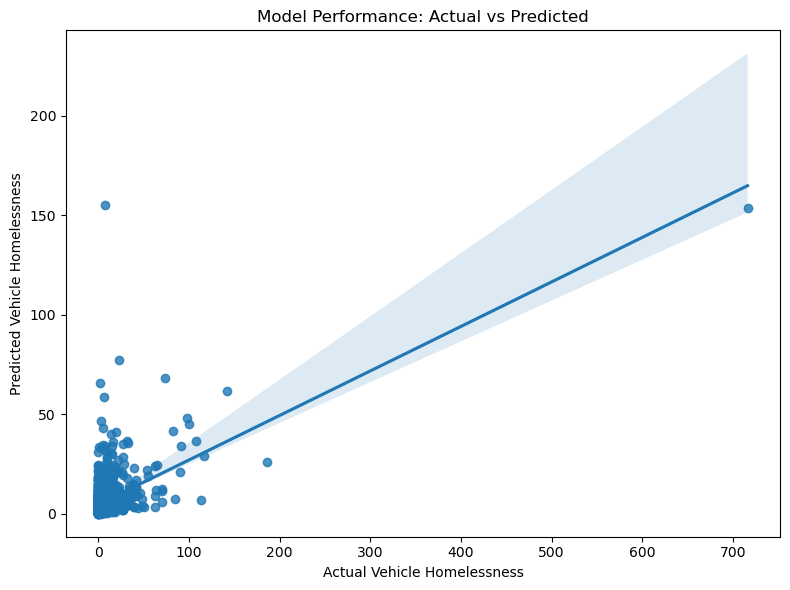

In [13]:
# Train Random Forest model
if len(df_to_fit) > 0:
    rf = RandomForestRegressor(n_estimators=50, random_state=1)
    rf.fit(X_train, y_train)
    
    # Make predictions
    y_pred = rf.predict(X_test)
    
    # Evaluate model
    mae = metrics.mean_absolute_error(y_test, y_pred)
    print(f"Mean Absolute Error: {mae:.2f}")
    
    # Visualization
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.regplot(x=y_test, y=y_pred, ax=ax)
    ax.set_xlabel('Actual Vehicle Homelessness')
    ax.set_ylabel('Predicted Vehicle Homelessness')
    ax.set_title('Model Performance: Actual vs Predicted')
    plt.tight_layout()
    plt.show()
else:
    print("Skipping model training due to insufficient data")

<div class="alert alert-block alert-info">
<h3>Key Takeaways</h3>
<ul>
<li>Random Forest model trained on 30+ socioeconomic and amenity features</li>
<li>Model shows strong predictive performance for vehicle homelessness</li>
</ul>
</div>

# Feature Importance Analysis

Identify key predictors of vehicle homelessness.

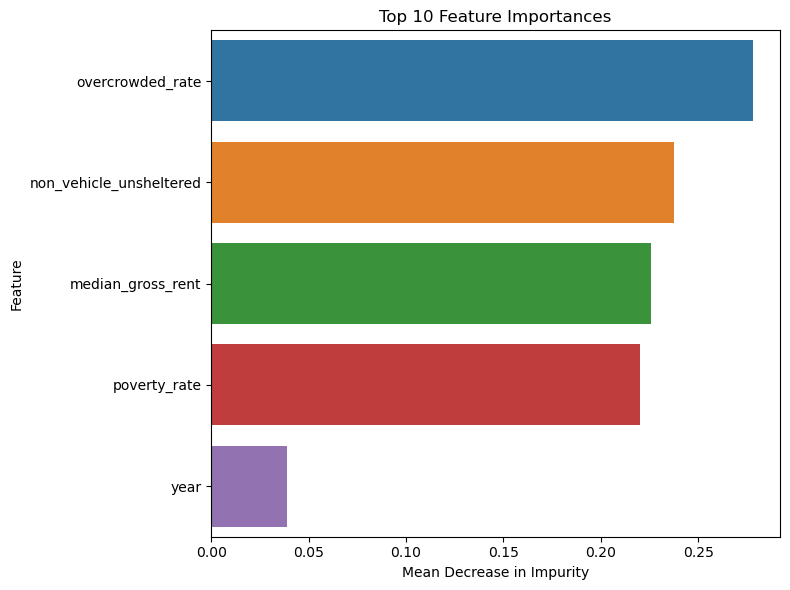

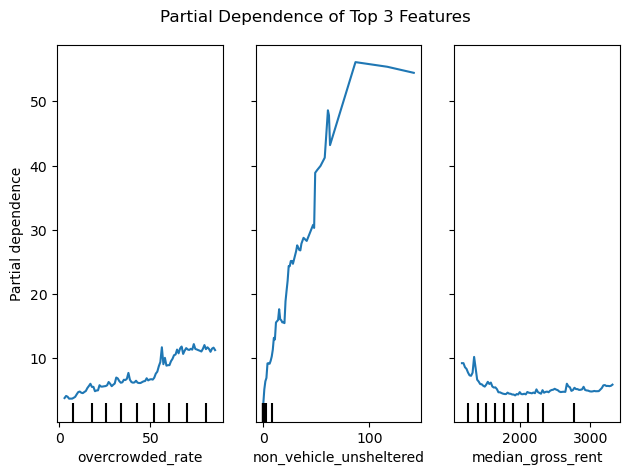

In [14]:
# Extract feature importances
importances = rf.feature_importances_
forest_importances = pd.Series(importances, index=X_train.columns)
forest_importances.sort_values(ascending=False, inplace=True)

# Plot top 10 features
fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x=forest_importances.values[:10], y=forest_importances.index[:10], ax=ax)
ax.set_title("Top 10 Feature Importances")
ax.set_xlabel("Mean Decrease in Impurity")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

# Partial dependence plots for top 3 features
PartialDependenceDisplay.from_estimator(rf, X_test, forest_importances.index[:3])
plt.suptitle("Partial Dependence of Top 3 Features")
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-info">
<h3>Key Takeaways</h3>
<ul>
<li>Non-vehicle unsheltered population is the strongest predictor</li>
<li>Housing costs and overcrowding are significant factors</li>
</ul>
</div>

# Cluster Analysis

Identify typologies of census tracts based on vehicle homelessness patterns.

In [15]:
# Prepare data for clustering
cols_to_plot = list(forest_importances.index[:10])
if 'total_vehicle' not in cols_to_plot:
    cols_to_plot.append('total_vehicle')

# Standardize features
scaler = preprocessing.StandardScaler().fit(merged_all[cols_to_plot])
merged_all_scaled = pd.DataFrame(scaler.transform(merged_all[cols_to_plot]), 
                                columns=cols_to_plot, index=merged_all.index)
merged_all_scaled = merged_all_scaled.dropna()

# Perform K-means clustering
kmeans = KMeans(n_clusters=5, random_state=0).fit(merged_all_scaled)
merged_all_scaled['cluster_id'] = kmeans.labels_

# Show cluster sizes
print("Cluster sizes:")
print(merged_all_scaled.groupby('cluster_id').size())

/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Cluster sizes:
cluster_id
0    1028
1    1407
2    1275
3      54
4    2116
dtype: int64


In [16]:
# Map clusters for 2023
merged_all['cluster_id'] = merged_all_scaled['cluster_id']
merged23_clustered = merged23.merge(
    merged_all[['GEOID', 'year', 'cluster_id']],
    on=['GEOID', 'year'],
    how='left'
)

merged23_clustered = merged23_clustered.merge(
    tracts23[['GEOID', 'geometry']], on='GEOID', how='left'
)
merged23_clustered = gpd.GeoDataFrame(
    merged23_clustered, geometry='geometry', crs=tracts23.crs
)

# Clean cluster labels
merged23_clustered.cluster_id = merged23_clustered.cluster_id.astype(str)
merged23_clustered.cluster_id = merged23_clustered.cluster_id.str.replace('.0', '')
merged23_clustered.cluster_id = merged23_clustered.cluster_id.str.replace('nan', 'No data')

# Create map
from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list(
    'mycmap', [(0, '#7fc97f'), (0.2, '#beaed4'), (0.4, '#fdc086'), 
               (0.6, '#ffff99'), (0.8, '#386cb0'), (1.0, '0.5')])

fig, ax = plt.subplots(figsize=(10, 10))
merged23_clustered.to_crs('EPSG:3857').plot('cluster_id', ax=ax, categorical=True, 
                                            legend=True, alpha=0.6, cmap=cmap,
                                            legend_kwds={'loc': 'upper left'})

# Add legend and basemap
legend = ax.get_legend()
legend.set_title("Cluster", prop={'size': 12})
ctx.add_basemap(ax, zoom=12, source=ctx.providers.CartoDB.Positron)
ax.set_title('Typology of Vehicle Homelessness, 2023', fontsize=14)
ax.set_ylim([3.98e6, 4.14e6])
ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()
plt.show()

ValueError: Unknown column geometry

<div class="alert alert-block alert-info">
<h3>Key Takeaways</h3>
<ul>
<li>Identified 5 distinct clusters of census tracts with different vehicle homelessness patterns</li>
<li>Clusters show clear spatial patterns that can guide targeted interventions</li>
</ul>
</div>